In [2]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm

rng = np.random.default_rng()

# Testing

In [52]:
g = ig.Graph.Famous("Zachary")
n_edges = g.ecount()
n_nodes = g.vcount()

In [19]:
min_prob = 0.5
probs = rng.uniform(min_prob, 1, size=g.ecount())
weights = - np.log(probs)
weights

array([0.226023  , 0.45614594, 0.69083432, 0.01842966, 0.34316804,
       0.68483081, 0.63437623, 0.18211686, 0.4530487 , 0.56450976,
       0.48695378, 0.0574874 , 0.3932734 , 0.17662756, 0.05423368,
       0.6225264 , 0.08502973, 0.03928821, 0.37882138, 0.25092732,
       0.15841037, 0.5375585 , 0.50269822, 0.40804945, 0.06879195,
       0.22975522, 0.0666991 , 0.52459906, 0.06471447, 0.05490337,
       0.17080906, 0.02846485, 0.36306097, 0.46197448, 0.26053295,
       0.24721295, 0.13469405, 0.46470595, 0.19305658, 0.38560305,
       0.06864564, 0.39839059, 0.61017113, 0.54844618, 0.27440759,
       0.33978778, 0.3666845 , 0.3863183 , 0.05861874, 0.18236147,
       0.13028343, 0.28121617, 0.12276601, 0.33285799, 0.36202325,
       0.25984442, 0.260855  , 0.65871724, 0.41449774, 0.34674894,
       0.43351721, 0.51915766, 0.08592995, 0.59214189, 0.63842632,
       0.07272421, 0.14852898, 0.44333261, 0.06734977, 0.23251815,
       0.26826737, 0.24562853, 0.38083553, 0.47782146, 0.15789

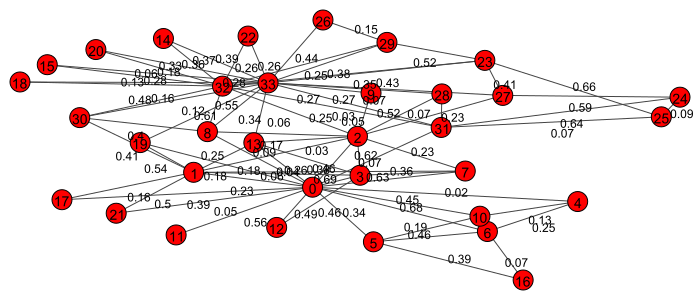

In [20]:
ig.plot(
    g,
    layout="auto",
    bbox=(700, 300),
    vertex_label=g.vs.indices,
    edge_label=np.round(weights, 2),
)

In [22]:
g.get_k_shortest_paths(16, 18, 10, weights=weights)

[[16, 6, 4, 0, 13, 2, 32, 18],
 [16, 6, 4, 0, 13, 2, 27, 33, 18],
 [16, 6, 4, 0, 1, 2, 32, 18],
 [16, 6, 4, 0, 1, 3, 2, 32, 18],
 [16, 6, 4, 0, 8, 2, 32, 18],
 [16, 6, 4, 0, 19, 33, 18],
 [16, 6, 4, 0, 13, 3, 2, 32, 18],
 [16, 6, 4, 0, 13, 1, 2, 32, 18],
 [16, 6, 4, 0, 13, 2, 27, 33, 15, 32, 18],
 [16, 6, 4, 0, 13, 1, 3, 2, 32, 18]]

In [23]:
g.get_diameter(weights=weights)

[11, 0, 13, 2, 32, 29, 26]

In [45]:
all_distances = np.array(g.distances(weights=weights))
all_distances = all_distances[np.triu_indices(g.vcount(), 1)]
all_distances = np.exp(-all_distances)

In [48]:
all_distances.min()

0.32977852321547124

In [25]:
np.exp(-g.diameter(weights=weights))

0.32977852321547124

# Minimum probability

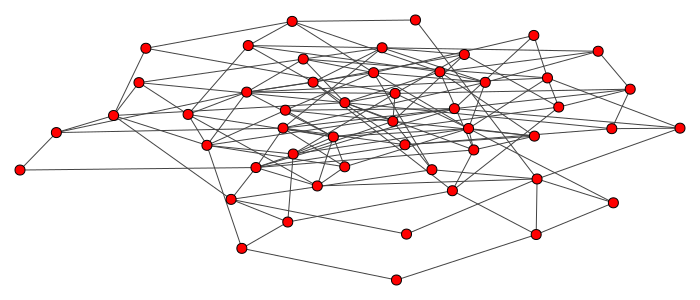

In [23]:
g = ig.Graph.Erdos_Renyi(50, 0.1)
n_edges = g.ecount()
n_nodes = g.vcount()
ig.plot(g, layout="graphopt", bbox=(700, 300), vertex_size=10)

In [77]:
n_probs = 100
depth = 1000
diameters = np.zeros(n_probs)
min_probs = np.linspace(0, 1, n_probs)
for idx, min_p in tqdm(enumerate(min_probs), total=n_probs):
    probs = rng.uniform(min_p, 1, size=(depth, n_edges))
    weights = - np.log(probs)
    for w in weights:
        diameters[idx] += np.exp(-g.diameter(weights=w))
    diameters[idx] /= depth

  0%|          | 0/100 [00:00<?, ?it/s]

[0.39681087 0.30871439 0.25048811 0.04336973]


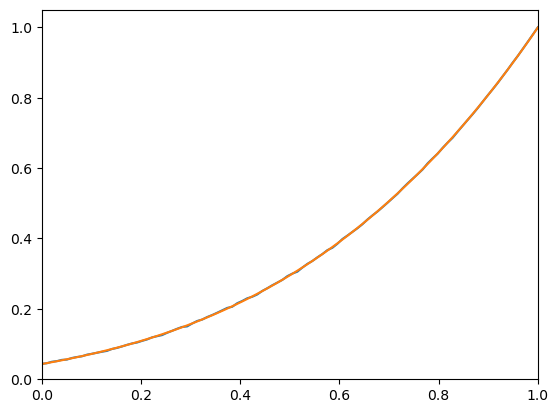

In [82]:
coeff = np.polyfit(min_probs, diameters, 3)
p = np.poly1d(coeff)
print(coeff)
# dx = min_probs[1] - min_probs[0]
plt.plot(min_probs, diameters)
plt.plot(min_probs, p(min_probs))
plt.xlim(0, 1)
plt.ylim(0, 1.05);

In [ ]:
n_probs = 100
depth = 1000
diameters = np.zeros(n_probs)
min_probs = np.linspace(0, 1, n_probs)
for idx, min_p in tqdm(enumerate(min_probs), total=n_probs):
    probs = rng.uniform(min_p, 1, size=(depth, n_edges))
    weights = - np.log(probs)
    for w in weights:
        diameters[idx] += np.exp(-g.diameter(weights=w))
    diameters[idx] /= depth

  0%|          | 0/100 [00:00<?, ?it/s]

[0.39681087 0.30871439 0.25048811 0.04336973]


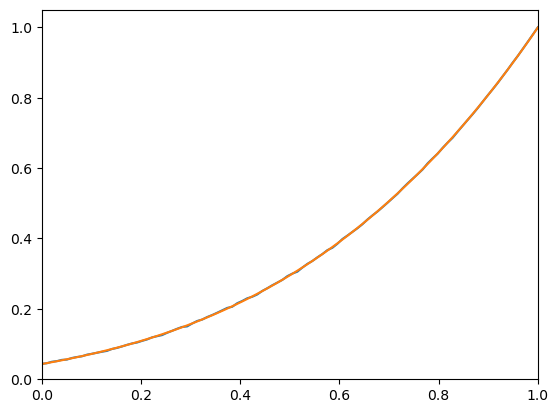

In [ ]:
coeff = np.polyfit(min_probs, diameters, 3)
p = np.poly1d(coeff)
print(coeff)
# dx = min_probs[1] - min_probs[0]
plt.plot(min_probs, diameters)
plt.plot(min_probs, p(min_probs))
plt.xlim(0, 1)
plt.ylim(0, 1.05);

# ITS NOT AN EXPONENTIAL

In [89]:
def func(x, A, B, C):
    return A * np.exp(B * (x - C))

In [90]:
popt, pcov = curve_fit(func, min_probs, diameters)
popt

array([1.60801836, 2.68141642, 1.15701442])

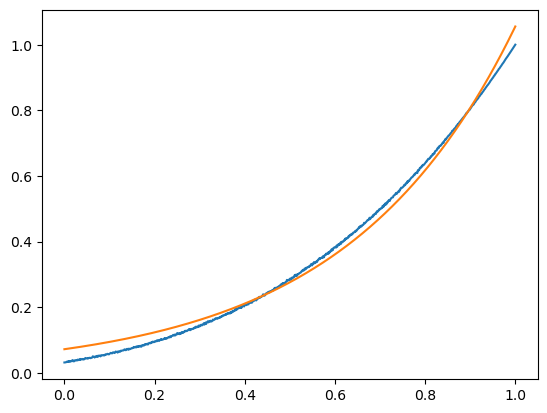

In [91]:
plt.plot(min_probs, diameters)
plt.plot(min_probs, func(min_probs, *popt))

# Vectorization test (useless)

In [ ]:
my_diam = lambda x: g.diameter(weights=x)
np_diameter = np.vectorize(my_diam, signature="(n)->()")

In [ ]:
n_probs = 100
depth = 1000
diameters = np.zeros(n_probs)
min_probs = np.linspace(0, 1, n_probs)
for idx, min_p in tqdm(enumerate(min_probs), total=n_probs):
    probs = rng.uniform(min_p, 1, size=(depth, n_edges))
    weights = - np.log(probs)
    all_diam = np.exp(-np_diameter(weights))
    diameters[idx] = all_diam.sum()
diameters /= depth

  0%|          | 0/100 [00:00<?, ?it/s]

[0.39681087 0.30871439 0.25048811 0.04336973]


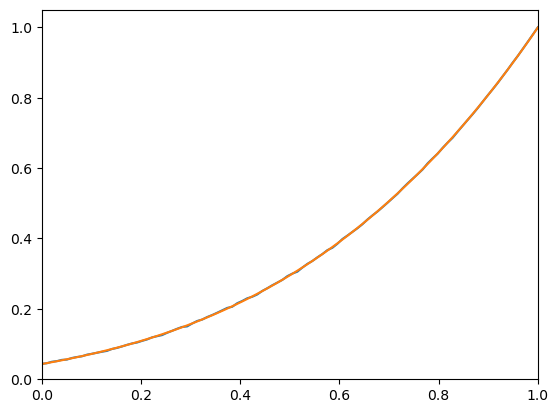

In [ ]:
coeff = np.polyfit(min_probs, diameters, 3)
p = np.poly1d(coeff)
print(coeff)
# dx = min_probs[1] - min_probs[0]
plt.plot(min_probs, diameters)
plt.plot(min_probs, p(min_probs))
plt.xlim(0, 1)
plt.ylim(0, 1.05);